In [ ]:
import pymysql
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Conexión
connection = pymysql.connect(
    host="212.227.90.6",
    user="Equipo27",
    password="****",
    database="Equip_27",
    port=3306
)

# Tablas
tablas = pd.read_sql("SHOW TABLES", connection).iloc[:, 0].tolist()

dfs = {}

for tabla in tablas:
    dfs[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", connection)

print(dfs.keys())

# Selección principal
df = dfs['BANK_marketing']

# Cerrar conexión 
connection.close()


C:\Users\GCCM_\AppData\Local\Temp\ipykernel_30988\2812867731.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tablas = pd.read_sql("SHOW TABLES", connection).iloc[:, 0].tolist()
C:\Users\GCCM_\AppData\Local\Temp\ipykernel_30988\2812867731.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", connection)


dict_keys(['BANK_marketing'])


## Análisis exploratorio de datos (EDA)

In [30]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10642 entries, 0 to 10641
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10642 non-null  int64  
 1   age        10633 non-null  float64
 2   job        10642 non-null  object 
 3   marital    10637 non-null  object 
 4   education  10635 non-null  object 
 5   default    10642 non-null  object 
 6   balance    10642 non-null  int64  
 7   housing    10642 non-null  object 
 8   loan       10642 non-null  object 
 9   contact    10642 non-null  object 
 10  day        10642 non-null  int64  
 11  month      10642 non-null  object 
 12  duration   10642 non-null  int64  
 13  campaign   10642 non-null  int64  
 14  pdays      10642 non-null  int64  
 15  previous   10642 non-null  int64  
 16  poutcome   10642 non-null  object 
 17  deposit    10642 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory usage: 1.5+ MB


In [32]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,10642.000000,10633.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000
mean,5321.500000,41.252610,1536.614828,15.645461,378.693197,2.496147,52.073670,0.851344
std,3072.225117,12.003015,3223.419300,8.432874,351.180910,2.694660,109.208889,2.321755
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,2661.250000,32.000000,127.000000,8.000000,141.000000,1.000000,-1.000000,0.000000
50%,5321.500000,39.000000,558.000000,15.000000,260.000000,2.000000,-1.000000,0.000000
75%,7981.750000,49.000000,1728.750000,22.000000,510.000000,3.000000,57.750000,1.000000
max,10642.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [33]:
df.isnull().sum()

id           0
age          9
job          0
marital      5
education    7
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [34]:
# Proporción de clientes que aceptan la campaña
df['deposit'].value_counts()

deposit
no     5353
yes    5289
Name: count, dtype: int64

In [35]:
# Proporción de clientes que aceptan la campaña
df['deposit'].value_counts(normalize=True)

deposit
no     0.503007
yes    0.496993
Name: proportion, dtype: float64

In [36]:
# Distribución y posibles valores extremos
df['age'].describe()

count    10633.000000
mean        41.252610
std         12.003015
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

<Axes: >

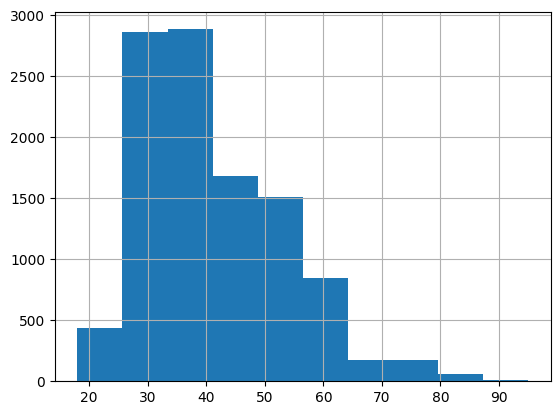

In [37]:
# Visualización de la distribución de la edad
df['age'].hist()

<Axes: >

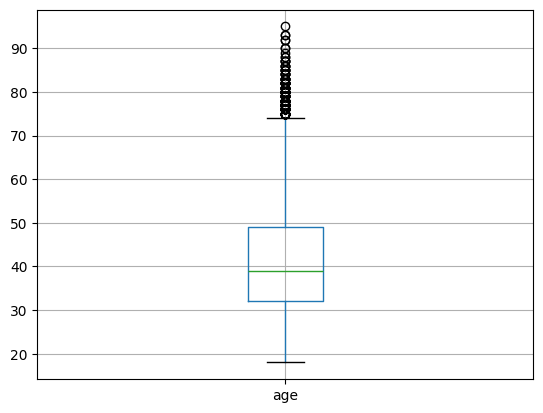

In [38]:
# Boxplot de la edad para visualizar la distribución y detectar posibles valores extremos
df.boxplot(column='age')

La edad se concentra principalmente entre los 20 y 60 años, con mayor densidad en el rango de 30 a 40 años, y algunos valores extremos en edades más elevadas.

In [39]:
# Frecuencia de tipos de trabajo
df['job'].value_counts()

job
management       2447
blue-collar      1830
technician       1737
admin.           1279
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
unknown            68
Name: count, dtype: int64

In [40]:
# Frecuencia de estado civil
df['marital'].value_counts()

marital
married     6030
single      3374
divorced    1233
Name: count, dtype: int64

In [41]:
# Frecuencia del nivel educativo
df['education'].value_counts()

education
secondary    5216
tertiary     3527
primary      1419
unknown       473
Name: count, dtype: int64

El perfil del cliente está dominado por personas casadas, con nivel educativo principalmente secundario o superior, y ocupaciones en sectores como management, técnico y blue-collar.

In [42]:
# Estadísticas del número de contactos para analizar dispersión y posibles outliers
df['campaign'].describe()

count    10642.000000
mean         2.496147
std          2.694660
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

<Axes: >

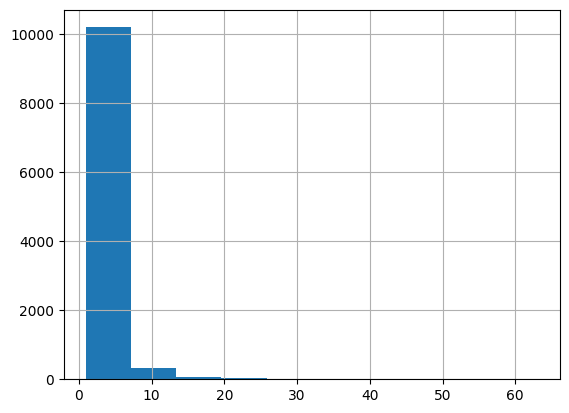

In [43]:
# Distribución del número de contactos
df['campaign'].hist()

<Axes: >

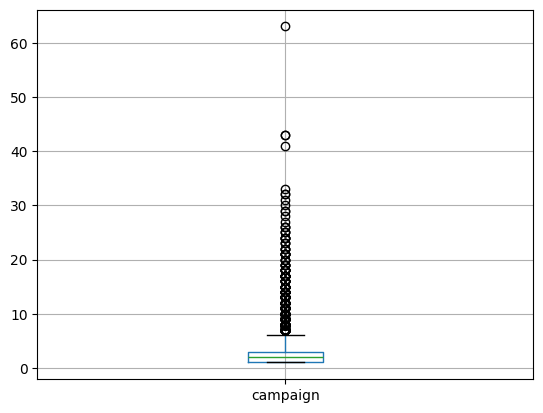

In [44]:
# Boxplot del número de contactos para analizar la dispersión y detectar posibles valores atípicos (outliers)
df.boxplot(column='campaign')

El número de contactos por cliente es generalmente bajo, concentrándose en menos de 3 intentos, aunque existen casos con valores significativamente más elevados.

In [45]:
# Frecuencia de los canales de contacto presentes en el dataset
df['contact'].value_counts()

contact
cellular     7707
unknown      2196
telephone     739
Name: count, dtype: int64

In [46]:
# Frecuencia por mes
df['month'].value_counts()

month
may    2646
aug    1450
jul    1429
jun    1174
nov     898
apr     888
feb     746
oct     387
jan     327
sep     314
mar     274
dec     109
Name: count, dtype: int64

El canal más utilizado es el contacto celular, y se observa una mayor concentración de campañas en determinados meses, como mayo, agosto y julio.

In [47]:
# Distribución de los saldos de los clientes
df['balance'].describe()

count    10642.000000
mean      1536.614828
std       3223.419300
min      -6847.000000
25%        127.000000
50%        558.000000
75%       1728.750000
max      81204.000000
Name: balance, dtype: float64

<Axes: >

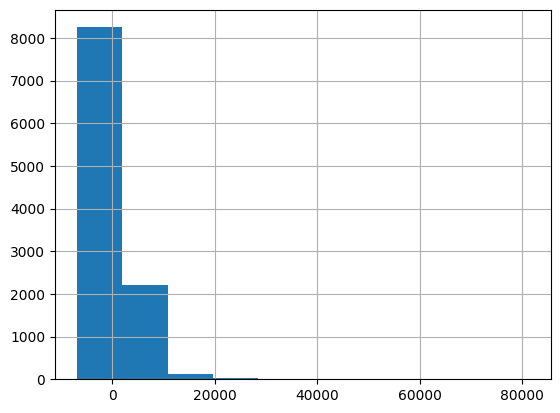

In [48]:
# Distribución del balance
df['balance'].hist()

<Axes: >

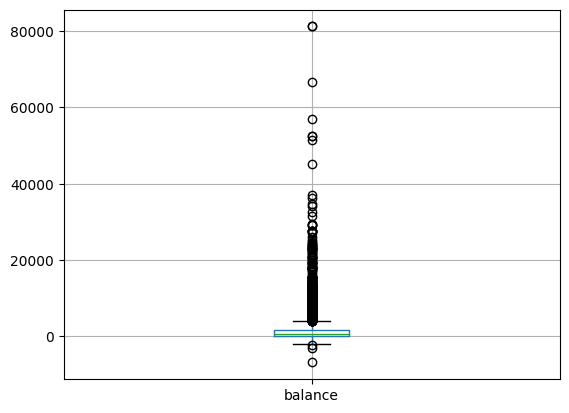

In [49]:
# # Boxplot del balance para identificar la dispersión y posibles valores atípicos (outliers)
df.boxplot(column='balance')

El balance presenta una distribución concentrada en valores bajos, con una alta dispersión y una notable presencia de valores atípicos, especialmente en la parte superior, lo que genera una distribución asimétrica.

In [50]:
# Presencia de préstamos personales
df['loan'].value_counts()

loan
no     9270
yes    1372
Name: count, dtype: int64

In [51]:
# Presencia de hipotecas
df['housing'].value_counts()

housing
no     5660
yes    4982
Name: count, dtype: int64

La mayoría de los clientes no dispone de préstamos personales, y existe una distribución relativamente equilibrada en cuanto a la posesión de hipoteca.

In [52]:
# Proporción de clientes en riesgo
df['default'].value_counts()

default
no     10487
yes      155
Name: count, dtype: int64

In [53]:
# Cómo se distribuye el balance en cada grupo
df.groupby('default')['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
no,10487.0,1560.420330,3239.504993,-3058.0,136.0,571.0,1757.0,81204.0
yes,155.0,-74.019355,854.137656,-6847.0,-360.0,0.0,66.0,5249.0


La proporción de clientes en situación de impago es muy reducida. Además, se observan diferencias en la distribución del balance entre clientes con y sin default.

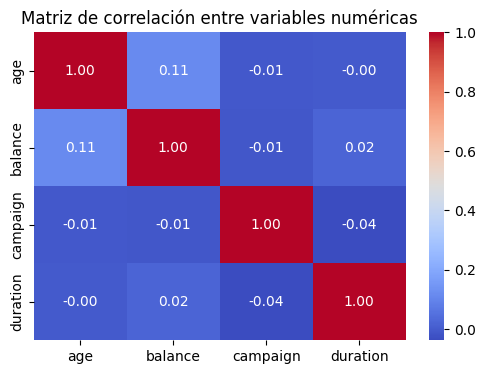

In [54]:
corr = df[['age','balance','campaign','duration']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

Se analizan las relaciones entre variables numéricas, observándose que no existen correlaciones lineales fuertes entre ellas.

# Conclusión

El dataset presenta una estructura completa y buena calidad de datos, con escasos valores nulos. La variable objetivo está equilibrada, lo que facilita el análisis posterior.

El perfil de cliente se concentra principalmente en personas casadas, con educación secundaria y ocupaciones en sectores como management, técnico y blue-collar.

El número de contactos suele ser bajo, aunque existen valores extremos, y el canal más utilizado es el contacto celular, con mayor actividad en ciertos meses.

El balance muestra una alta dispersión, incluyendo valores extremos, mientras que las situaciones de impago son poco frecuentes.

Además, el análisis de correlación indica que no existen relaciones lineales fuertes entre las variables numéricas.

En conjunto, los datos permiten abordar análisis posteriores desde distintas perspectivas de negocio.
